Assignment 30

by Annisa DSML 43

# Airline Customer Segmentation Using K-Means Clustering


## Project Overview

Project ini berfokus pada segmentasi pelanggan di industri penerbangan menggunakan K-Means Clustering. Pelanggan dikelompokkan berdasarkan perilaku perjalanan mereka, durasi keanggotaan, frekuensi penerbangan, total jarak perjalanan, waktu perjalanan terakhir, dan rata-rata diskon yang diterima.

- Main Objective: Mengelompokkan pelanggan maskapai berdasarkan pola perjalanan mereka menggunakan K-Means Clustering serta memberikan rekomendasi bisnis yang sesuai untuk setiap segmen pelanggan.


- Spesific objective:

1. Mempersiapkan dan memproses data pelanggan maskapai penerbangan untuk analisis clustering.
2. Menjelajahi pola perjalanan pelanggan melalui Analisis Data Eksplorasi.
Melakukan segmentasi pelanggan menggunakan K-Means Clustering.
3. Menentukan jumlah cluster yang tepat menggunakan Metode Elbow dan Skor Silhouette.
4. Mengidentifikasi karakteristik setiap segmen pelanggan.
5. Memberikan rekomendasi bisnis yang dapat ditindaklanjuti berdasarkan hasil clustering.

# Import Library

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# Style visualisasi
plt.style.use("fivethirtyeight")

sns.set(rc={'figure.figsize':(20.7, 8.27)})
sns.set_style("whitegrid")
sns.set_palette([
    "#7B2D5F",
    "#A64D79",
    "#C97FA3",
    "#E4A6C2",
    "#F2C6D8"
])

# 1. Data Preprocessing

## Load Dataset

In [3]:
df = pd.read_csv('flight.csv')
df.head()

,MEMBER_NO,FFP_DATE,FIRST_FLIGHT_DATE,GENDER,FFP_TIER,WORK_CITY,WORK_PROVINCE,WORK_COUNTRY,AGE,LOAD_TIME,...,SUM_YR_2,SEG_KM_SUM,LAST_FLIGHT_DATE,LAST_TO_END,AVG_INTERVAL,MAX_INTERVAL,EXCHANGE_COUNT,avg_discount,Points_Sum,Point_NotFlight
0,54993,11/2/2006,12/24/2008,Male,6,.,beijing,CN,31.0,3/31/2014,...,234188.0,580717,3/31/2014,1,3.483254,18,34,0.961639,619760,50
1,28065,2/19/2007,8/3/2007,Male,6,NaN,beijing,CN,42.0,3/31/2014,...,167434.0,293678,3/25/2014,7,5.194245,17,29,1.252314,415768,33
2,55106,2/1/2007,8/30/2007,Male,6,.,beijing,CN,40.0,3/31/2014,...,164982.0,283712,3/21/2014,11,5.298507,18,20,1.254676,406361,26
3,21189,8/22/2008,8/23/2008,Male,5,Los Angeles,CA,US,64.0,3/31/2014,...,125500.0,281336,12/26/2013,97,27.863636,73,11,1.090870,372204,12
4,39546,4/10/2009,4/15/2009,Male,6,guiyang,guizhou,CN,48.0,3/31/2014,...,130702.0,309928,3/27/2014,5,4.788079,47,27,0.970658,338813,39


## Data Type dan Informasi Dataset

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62988 entries, 0 to 62987
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   MEMBER_NO          62988 non-null  int64  
 1   FFP_DATE           62988 non-null  object 
 2   FIRST_FLIGHT_DATE  62988 non-null  object 
 3   GENDER             62985 non-null  object 
 4   FFP_TIER           62988 non-null  int64  
 5   WORK_CITY          60719 non-null  object 
 6   WORK_PROVINCE      59740 non-null  object 
 7   WORK_COUNTRY       62962 non-null  object 
 8   AGE                62568 non-null  float64
 9   LOAD_TIME          62988 non-null  object 
 10  FLIGHT_COUNT       62988 non-null  int64  
 11  BP_SUM             62988 non-null  int64  
 12  SUM_YR_1           62437 non-null  float64
 13  SUM_YR_2           62850 non-null  float64
 14  SEG_KM_SUM         62988 non-null  int64  
 15  LAST_FLIGHT_DATE   62988 non-null  object 
 16  LAST_TO_END        629

In [5]:
# cek missing value
df.isnull().sum()

,0
MEMBER_NO,0
FFP_DATE,0
FIRST_FLIGHT_DATE,0
GENDER,3
FFP_TIER,0
WORK_CITY,2269
WORK_PROVINCE,3248
WORK_COUNTRY,26
AGE,420
LOAD_TIME,0


In [6]:
#cek percentage missing value
(df.isnull().sum() / len(df) * 100).round(2)

,0
MEMBER_NO,0.00
FFP_DATE,0.00
FIRST_FLIGHT_DATE,0.00
GENDER,0.00
FFP_TIER,0.00
WORK_CITY,3.60
WORK_PROVINCE,5.16
WORK_COUNTRY,0.04
AGE,0.67
LOAD_TIME,0.00


In [7]:
#cek duplikat
df.duplicated().sum()

np.int64(0)

In [8]:
df.describe()

,MEMBER_NO,FFP_TIER,AGE,FLIGHT_COUNT,BP_SUM,SUM_YR_1,SUM_YR_2,SEG_KM_SUM,LAST_TO_END,AVG_INTERVAL,MAX_INTERVAL,EXCHANGE_COUNT,avg_discount,Points_Sum,Point_NotFlight
count,62988.000000,62988.000000,62568.000000,62988.000000,62988.000000,62437.000000,62850.000000,62988.000000,62988.000000,62988.000000,62988.000000,62988.000000,62988.000000,62988.0000,62988.000000
mean,31494.500000,4.102162,42.476346,11.839414,10925.081254,5355.376064,5604.026014,17123.878691,176.120102,67.749788,166.033895,0.319775,0.721558,12545.7771,2.728155
std,18183.213715,0.373856,9.885915,14.049471,16339.486151,8109.450147,8703.364247,20960.844623,183.822223,77.517866,123.397180,1.136004,0.185427,20507.8167,7.364164
min,1.000000,4.000000,6.000000,2.000000,0.000000,0.000000,0.000000,368.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000
25%,15747.750000,4.000000,35.000000,3.000000,2518.000000,1003.000000,780.000000,4747.000000,29.000000,23.370370,79.000000,0.000000,0.611997,2775.0000,0.000000
50%,31494.500000,4.000000,41.000000,7.000000,5700.000000,2800.000000,2773.000000,9994.000000,108.000000,44.666667,143.000000,0.000000,0.711856,6328.5000,0.000000
75%,47241.250000,4.000000,48.000000,15.000000,12831.000000,6574.000000,6845.750000,21271.250000,268.000000,82.000000,228.000000,0.000000,0.809476,14302.5000,1.000000
max,62988.000000,6.000000,110.000000,213.000000,505308.000000,239560.000000,234188.000000,580717.000000,731.000000,728.000000,728.000000,46.000000,1.500000,985572.0000,140.000000


Interpretasi:

Missing value terdapat pada beberapa kolom seperti lokasi, umur, dan data point tahunan. Namun fitur yang dipilih untuk proses clustering berfokus pada perilaku perjalanan customer dan tidak menggunakan kolom-kolom tersebut. Karena itu, missing value pada kolom yang tidak digunakan tidak diimputasi agar tidak menambahkan asumsi yang tidak diperlukan.

Setelah feature engineering, missing value pada fitur model akan dicek kembali dan hanya baris yang tidak lengkap pada fitur model yang akan dihapus.

## Data Cleaning, Feature Engineering & Feature Selection

In [9]:
# Ubah kolom tanggal menjadi datetime
df['FFP_DATE'] = pd.to_datetime(df['FFP_DATE'], errors='coerce')
df['LOAD_TIME'] = pd.to_datetime(df['LOAD_TIME'], errors='coerce')

# L = lama customer menjadi member (dalam bulan)
df['L'] = (df['LOAD_TIME'] - df['FFP_DATE']).dt.days / 30

df[['FFP_DATE', 'LOAD_TIME', 'L']].head()

,FFP_DATE,LOAD_TIME,L
0,2006-11-02,2014-03-31,90.200000
1,2007-02-19,2014-03-31,86.566667
2,2007-02-01,2014-03-31,87.166667
3,2008-08-22,2014-03-31,68.233333
4,2009-04-10,2014-03-31,60.533333


Interpretasi Feature Engineering:

Feature L dibuat untuk merepresentasikan lama customer menjadi member Frequent Flyer Program, yang dihitung dari selisih antara LOAD_TIME dan FFP_DATE dalam satuan bulan.

**Fitur yang digunakan untuk clustering**

Fitur dipilih agar mewakili pola dan nilai perjalanan customer:

- L: lama menjadi member frequent flyer (bulan)
- LAST_TO_END: Jarak waktu penerbangan terakhir ke pesanan penerbangan paling akhir
- FLIGHT_COUNT:  Jumlah penerbangan Customer
- SEG_KM_SUM: Total jarak(km) penerbangan yg sudah dilakukan
- avg_discount: Rata rata discount yang didapat customer
- Kolom MEMBER_NO tidak digunakan karena hanya berfungsi sebagai ID customer.
- Kolom kategorikal seperti kota, negara, dan gender juga tidak digunakan pada model K-Means ini karena model difokuskan pada perilaku perjalanan numerik.

In [10]:
feats = ['L', 'LAST_TO_END', 'FLIGHT_COUNT', 'SEG_KM_SUM', 'avg_discount']

df_model = df[feats].copy()

print('Missing value pada fitur model sebelum cleaning:')
print(df_model.isnull().sum())


Missing value pada fitur model sebelum cleaning:
L               0
LAST_TO_END     0
FLIGHT_COUNT    0
SEG_KM_SUM      0
avg_discount    0
dtype: int64


# 2. Exploratory Data Analysis (EDA)

## Statistik Deskriptif

In [11]:
df_model.describe().T

,count,mean,std,min,25%,50%,75%,max
L,62988.0,49.500028,28.240765,12.166667,24.400000,42.333333,72.633333,114.566667
LAST_TO_END,62988.0,176.120102,183.822223,1.000000,29.000000,108.000000,268.000000,731.000000
FLIGHT_COUNT,62988.0,11.839414,14.049471,2.000000,3.000000,7.000000,15.000000,213.000000
SEG_KM_SUM,62988.0,17123.878691,20960.844623,368.000000,4747.000000,9994.000000,21271.250000,580717.000000
avg_discount,62988.0,0.721558,0.185427,0.000000,0.611997,0.711856,0.809476,1.500000


## Distribusi Feature

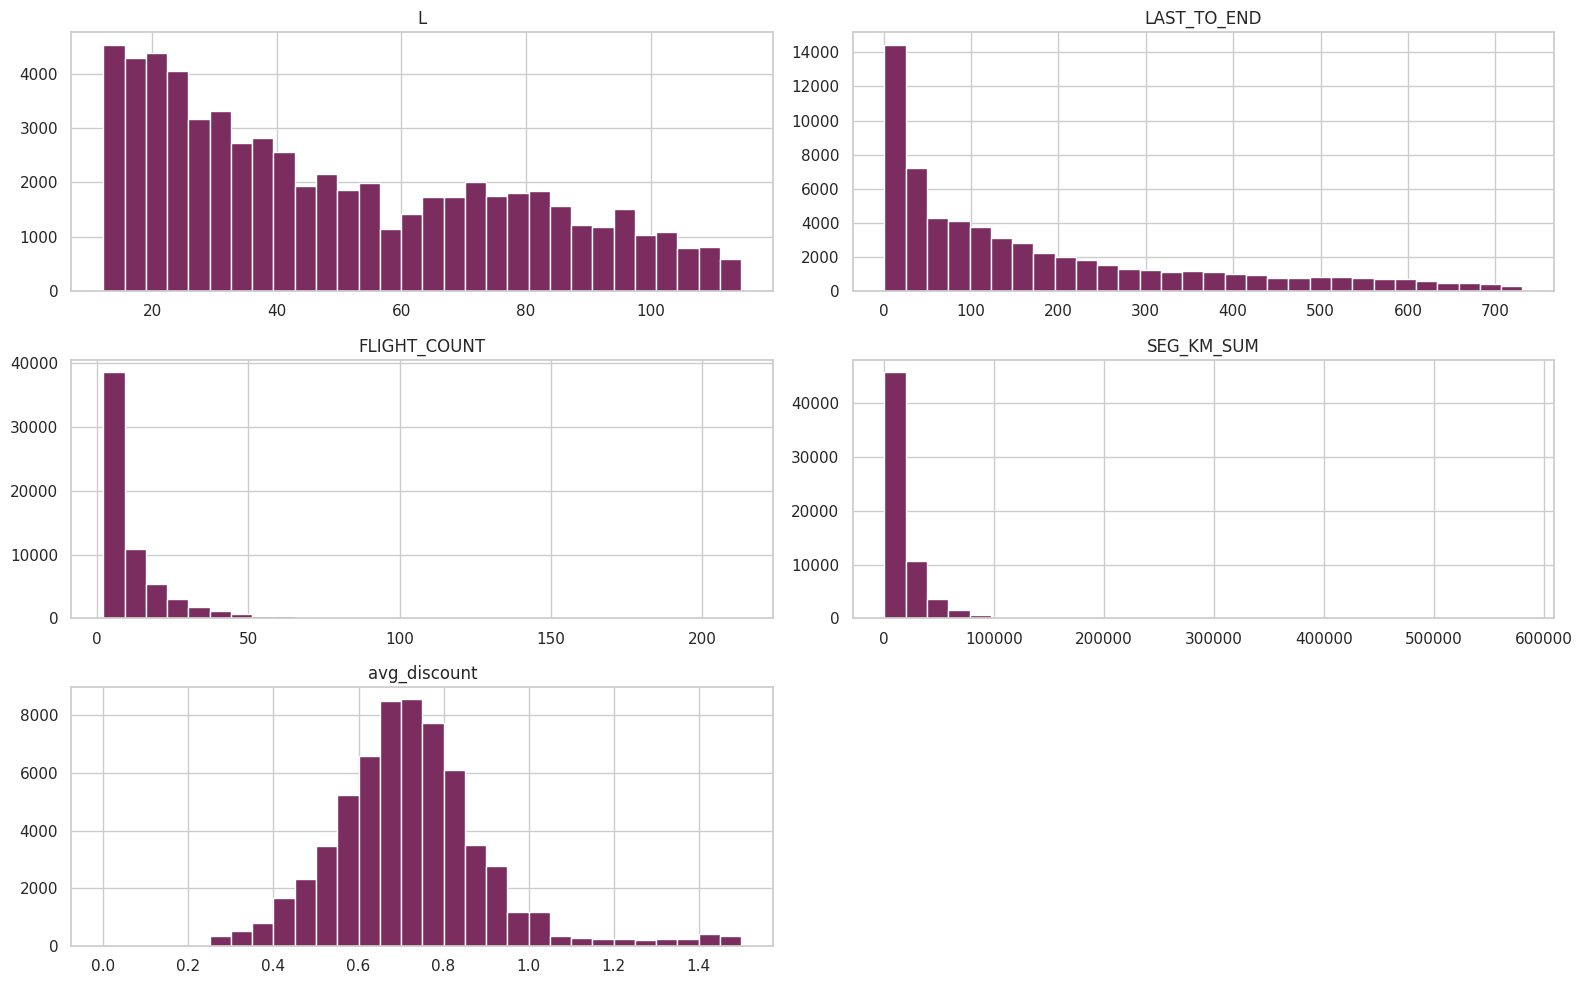

In [12]:
df_model.hist(figsize=(16, 10), bins=30)
plt.tight_layout()
plt.show()

Interpretasi:

Dari distribusi awal terlihat beberapa fitur seperti FLIGHT_COUNT dan SEG_KM_SUM memiliki rentang yang jauh lebih besar dibanding fitur lain. Karena K-Means menghitung jarak antar titik, perbedaan skala ini perlu ditangani dengan standardisasi nantinya

## Correlation Analysis

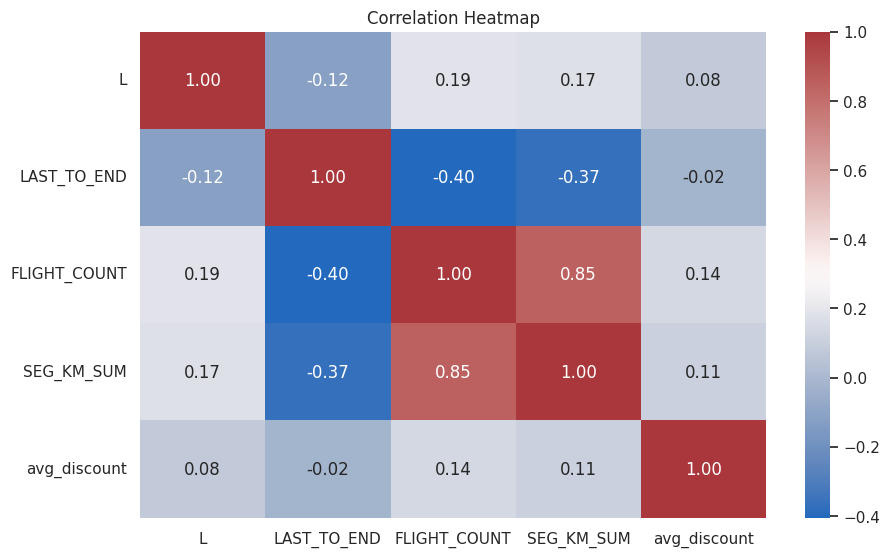

In [13]:
plt.figure(figsize=(9, 6))
sns.heatmap(df_model.corr(), annot=True, cmap='vlag', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

Interpretasi:

- Berdasarkan correlation heatmap, hubungan paling kuat terdapat antara FLIGHT_COUNT dan SEG_KM_SUM dengan korelasi 0.85, yang menunjukkan bahwa customer dengan frekuensi penerbangan lebih tinggi cenderung memiliki total jarak perjalanan yang lebih besar.
- LAST_TO_END memiliki korelasi negatif sedang dengan FLIGHT_COUNT (-0.40) dan SEG_KM_SUM (-0.37), yang menunjukkan bahwa customer yang sudah lama tidak melakukan penerbangan cenderung memiliki aktivitas perjalanan yang lebih rendah.
- Sementara itu, L dan avg_discount memiliki korelasi relatif rendah terhadap fitur lainnya.

## Scatter Plot

Hubungan Flight Count dan Total Jarak

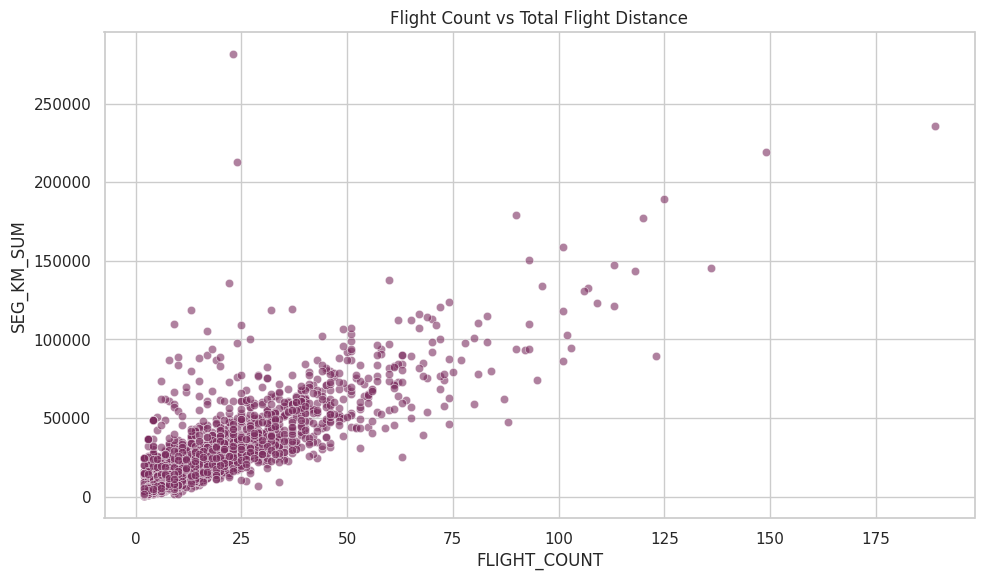

In [14]:
# Sampling untuk membuat scatter plot lebih mudah dibaca
eda_sample = df_model.sample(n=min(5000, len(df_model)), random_state=0)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=eda_sample,
                x='FLIGHT_COUNT',
                y='SEG_KM_SUM',
                alpha=0.6)
plt.title('Flight Count vs Total Flight Distance')
plt.show()


Interpretasi:

- Terlihat pola titik yang bergerak naik dari kiri bawah ke kanan atas, sehingga menunjukkan hubungan positif antara jumlah penerbangan dan total jarak perjalanan.
- Hal ini konsisten dengan hasil correlation heatmap sebelumnya, yaitu korelasi sebesar 0.85.
- Selain itu, terdapat beberapa titik yang jauh dari kelompok utama, yang menunjukkan adanya customer dengan aktivitas penerbangan sangat tinggi dibandingkan mayoritas customer.

## Standarisasi Feature

In [15]:
# Karena K-Means menggunakan perhitungan jarak, fitur perlu di-scaling
X = df_model[feats].values

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_std = scaler.fit_transform(X)
new_df = pd.DataFrame(data = X_std, columns = feats)
new_df.describe()


,L,LAST_TO_END,FLIGHT_COUNT,SEG_KM_SUM,avg_discount
count,6.298800e+04,6.298800e+04,6.298800e+04,6.298800e+04,6.298800e+04
mean,3.140520e-16,2.887835e-17,-1.010742e-16,-4.331752e-17,-1.010742e-16
std,1.000008e+00,1.000008e+00,1.000008e+00,1.000008e+00,1.000008e+00
min,-1.321978e+00,-9.526677e-01,-7.003461e-01,-7.993958e-01,-3.891369e+00
25%,-8.887942e-01,-8.003454e-01,-6.291685e-01,-5.904808e-01,-5.908618e-01
50%,-2.537733e-01,-3.705789e-01,-3.444580e-01,-3.401550e-01,-5.231986e-02
75%,8.191524e-01,4.998342e-01,2.249630e-01,1.978644e-01,4.741442e-01
max,2.304015e+00,3.018592e+00,1.431813e+01,2.688811e+01,4.198148e+00


# 3. Clustering dengan K-Means

## Evaluasi K-Means dengan Elbow Method

In [16]:
from sklearn.cluster import KMeans
inertia = []
for i in range(1, 11):
  kmeans = KMeans(n_clusters=i, random_state=0)
  kmeans.fit(new_df.values)
  nilai_inertia = kmeans.inertia_
  inertia.append(nilai_inertia)
  print('jumlah cluster : ',i, 'nilai intertia : ', nilai_inertia)

jumlah cluster :  1 nilai intertia :  314939.9999999993
jumlah cluster :  2 nilai intertia :  232663.90056704183
jumlah cluster :  3 nilai intertia :  186834.19972666283
jumlah cluster :  4 nilai intertia :  153137.39025115
jumlah cluster :  5 nilai intertia :  135422.99675322406
jumlah cluster :  6 nilai intertia :  119923.8935627644
jumlah cluster :  7 nilai intertia :  109272.63005435768
jumlah cluster :  8 nilai intertia :  102252.01889441157
jumlah cluster :  9 nilai intertia :  96620.32953261571
jumlah cluster :  10 nilai intertia :  90256.3819441509


In [17]:
inertia

[314939.9999999993,
 232663.90056704183,
 186834.19972666283,
 153137.39025115,
 135422.99675322406,
 119923.8935627644,
 109272.63005435768,
 102252.01889441157,
 96620.32953261571,
 90256.3819441509]

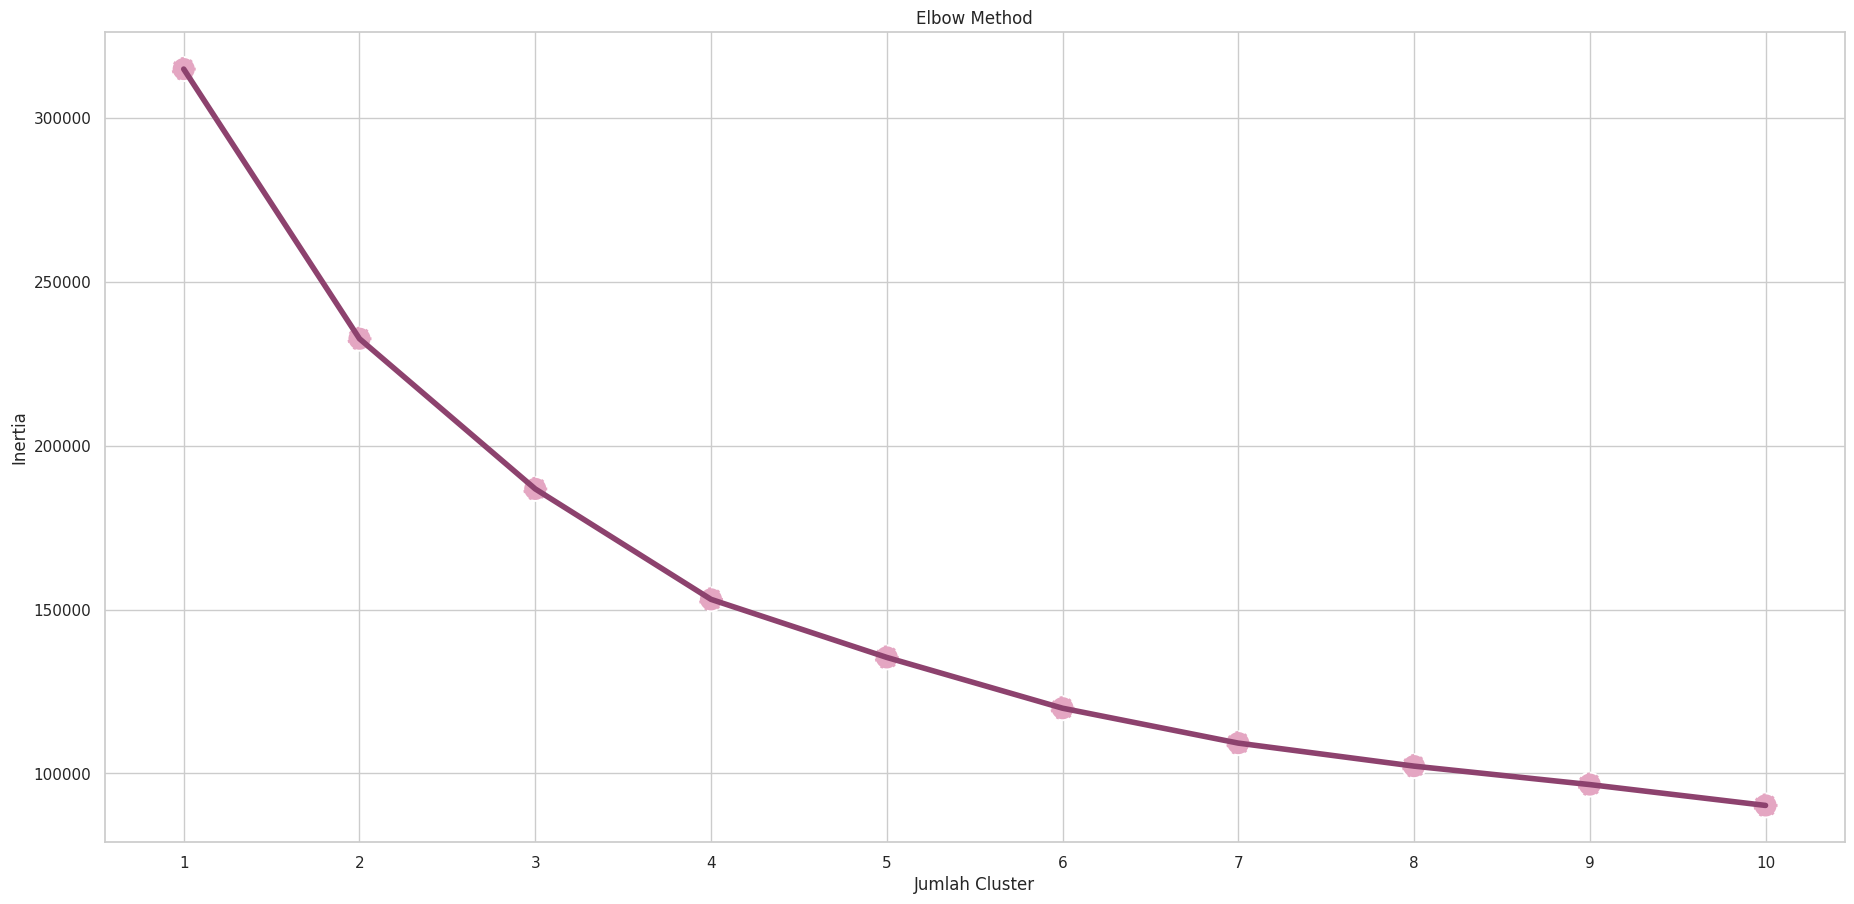

In [18]:
plt.figure(figsize=(20, 10))

sns.lineplot(x=range(1, 11), y=inertia, color='#8D426E', linewidth = 4)
sns.scatterplot(x=range(1, 11), y=inertia, s=300, color='#E4A6C2',  linestyle='--')

plt.xlabel('Jumlah Cluster')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.xticks(range(1, 11))
plt.show()

Interpretasi:

- Berdasarkan Elbow Method, jumlah cluster yang paling potensial berada di sekitar k=4 dan k=5 karena penurunan inertia mulai melandai setelah titik tersebut.
- Hal ini menunjukkan bahwa penambahan cluster di atas 4 dan 5 memberikan pengurangan inertia yang semakin kecil.
- Oleh karena itu, k=4 dan k=5 dapat dipertimbangkan sebagai kandidat jumlah cluster yang optimal dan perlu dibandingkan kembali dengan Silhouette Score.

## Evaluasi dengan Silhouette Score

In [19]:
from sklearn.metrics import silhouette_score

range_n_clusters = list(range(2,11))
print(range_n_clusters)

[2, 3, 4, 5, 6, 7, 8, 9, 10]


In [20]:
arr_silhouette_score_euclidean = []
for i in range_n_clusters:
    kmeans = KMeans(n_clusters=i, random_state=0, n_init=10).fit(new_df)
    preds = kmeans.predict(new_df)

    # Sampling digunakan agar perhitungan silhouette lebih efisien pada dataset besar
    score_euclidean = silhouette_score(
        new_df,
        preds,
        metric='euclidean',
        sample_size=min(10000, len(new_df)),
        random_state=0
    )
    arr_silhouette_score_euclidean.append(score_euclidean)

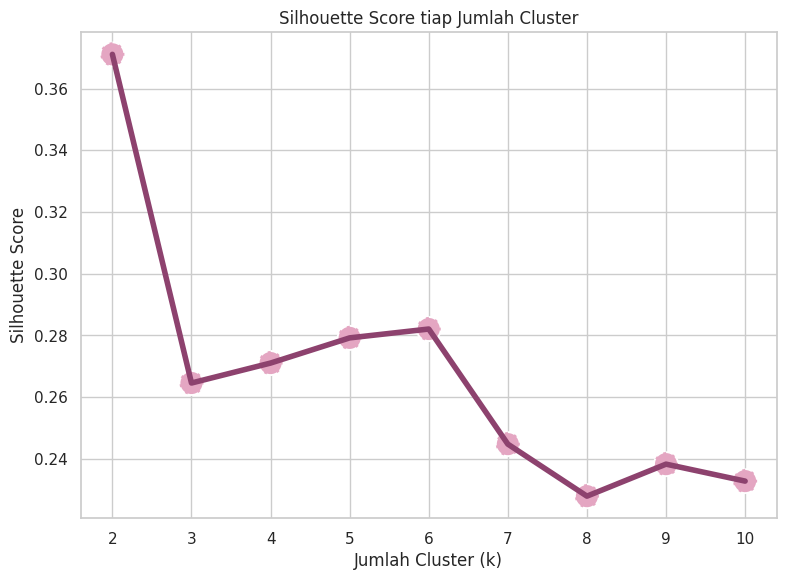

In [21]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.lineplot(x=range(2,11), y=arr_silhouette_score_euclidean, color='#8D426E', linewidth = 4)
sns.scatterplot(x=range(2,11), y=arr_silhouette_score_euclidean, s=300, color='#E4A6C2',  linestyle='--')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score tiap Jumlah Cluster')
plt.show()

Interpretasi

- Berdasarkan Silhouette Score, nilai tertinggi diperoleh pada k=2, yang menunjukkan pemisahan cluster paling baik secara matematis.
- Namun, untuk kebutuhan segmentasi yang lebih detail, k=4 hingga k=6 masih dapat dipertimbangkan.
- Di antara rentang tersebut, k=6 memiliki Silhouette Score sedikit lebih tinggi, sedangkan k=5 juga memberikan nilai yang relatif baik.
- Pemilihan cluster final selanjutnya dipertimbangkan bersama hasil Elbow Method dan kemudahan interpretasi karakteristik tiap cluster.

## Membandingkan Kandidat k = 4, 5, dan 6

In [22]:
candidate_k = [4, 5, 6]

# Fit KMeans models for a range of k
kmeans_models = {}
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=0, n_init=10)
    kmeans.fit(new_df)
    kmeans_models[k] = kmeans

candidate_profiles = {}

for k in candidate_k:
    labels = kmeans_models[k].labels_

    temp = df_model.copy()
    temp['cluster'] = labels
    candidate_profiles[k] = temp.groupby('cluster')[feats].mean().round(2)

    print(f'K = {k} ')
    display(candidate_profiles[k])

K = 4 


,L,LAST_TO_END,FLIGHT_COUNT,SEG_KM_SUM,avg_discount
cluster,,,,,
0,29.91,99.80,9.50,13630.42,0.70
1,81.77,108.17,10.52,14962.58,0.74
2,40.61,477.37,3.82,5894.49,0.72
3,63.04,28.19,46.18,67212.89,0.79


K = 5 


,L,LAST_TO_END,FLIGHT_COUNT,SEG_KM_SUM,avg_discount
cluster,,,,,
0,51.53,176.33,8.65,12316.24,1.13
1,29.82,98.35,9.64,13835.76,0.68
2,40.33,481.99,3.79,5877.47,0.69
3,63.29,27.67,46.88,68182.44,0.78
4,82.41,106.36,10.64,15174.96,0.69


K = 6 


,L,LAST_TO_END,FLIGHT_COUNT,SEG_KM_SUM,avg_discount
cluster,,,,,
0,82.48,120.80,8.51,12135.53,0.69
1,56.79,42.23,29.86,42712.95,0.74
2,69.30,18.33,66.50,98267.34,0.82
3,40.01,488.32,3.79,5852.02,0.70
4,29.25,108.31,7.98,11434.63,0.68
5,54.49,159.94,10.45,15292.03,1.23


## Pemilihan Jumlah Cluster

- Hasil perbandingan menunjukkan k=4 menghasilkan segmentasi yang lebih sederhana, tetapi customer dengan rata-rata discount sangat tinggi belum terbentuk sebagai segmen tersendiri.
- k=5 membentuk lima pola yang lebih mudah diinterpretasikan: customer discount-sensitive, new/developing regular, inactive/at-risk, high-value active, dan long-term regular.
- k=6 memiliki Silhouette Score sangat sedikit lebih tinggi dibanding k=5 pada sampling ini, tetapi membagi customer dengan aktivitas tinggi menjadi kelompok yang lebih granular sehingga interpretasi bisnis menjadi lebih kompleks.
- Dengan mempertimbangkan Elbow Method, Silhouette Score, perbedaan mean antar cluster, dan kemudahan interpretasi bisnis, k=5 dipilih sebagai solusi final.

## Final K-Means Model

In [23]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=5, random_state=0,n_init=10)
kmeans.fit(new_df.values)

KMeans(n_clusters=5, n_init=10, random_state=0)

In [24]:
df_cluster = df.loc[df_model.index].copy()
df_cluster['cluster'] = kmeans.labels_

In [25]:
df_cluster[['MEMBER_NO'] + feats + ['cluster']].head()

,MEMBER_NO,L,LAST_TO_END,FLIGHT_COUNT,SEG_KM_SUM,avg_discount,cluster
0,54993,90.200000,1,210,580717,0.961639,3
1,28065,86.566667,7,140,293678,1.252314,3
2,55106,87.166667,11,135,283712,1.254676,3
3,21189,68.233333,97,23,281336,1.090870,3
4,39546,60.533333,5,152,309928,0.970658,3


# 4. Visualisasi Hasil Clustering

## Jumlah Customer per Cluster

In [26]:
cluster_count = df_cluster['cluster'].value_counts().sort_index()
cluster_distribution = pd.DataFrame({
    'customer_count': cluster_count,
    'percentage': (cluster_count / len(df_cluster) * 100).round(2)
})

cluster_distribution

,customer_count,percentage
cluster,,
0,4215,6.69
1,24931,39.58
2,12571,19.96
3,5378,8.54
4,15893,25.23


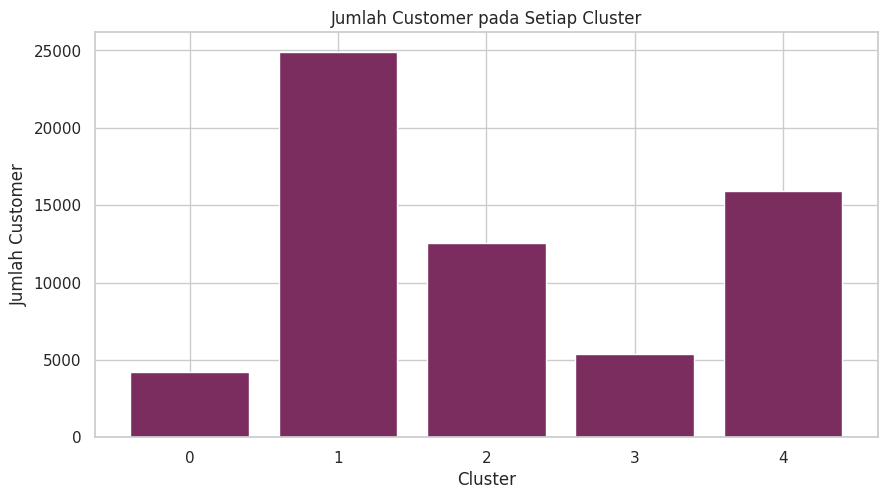

In [27]:
plt.figure(figsize=(9, 5))
plt.bar(cluster_count.index.astype(str), cluster_count.values)
plt.xlabel('Cluster')
plt.ylabel('Jumlah Customer')
plt.title('Jumlah Customer pada Setiap Cluster')
plt.show()

Interpretasi:

- Cluster 1 memiliki jumlah customer paling banyak, sekitar 25 ribu customer, diikuti Cluster 4 sekitar 16 ribu dan Cluster 2 sekitar 12 ribu. Sementara itu, Cluster 0 dan Cluster 3 memiliki jumlah customer yang lebih sedikit, masing-masing sekitar 4–5 ribu customer.

- Perbedaan ukuran cluster ini menunjukkan bahwa sebagian besar customer memiliki karakteristik yang mirip dengan Cluster 1 dan Cluster 4, sedangkan Cluster 0 dan Cluster 3 merupakan kelompok yang lebih spesifik.

## Visualisasi Cluster dan Centroid

In [28]:
cluster_palette = {
    0: '#5B1A3C',
    1: '#A64D79',
    2: '#7A5195',
    3: '#E07A9A',
    4: '#F2B5D4'
}

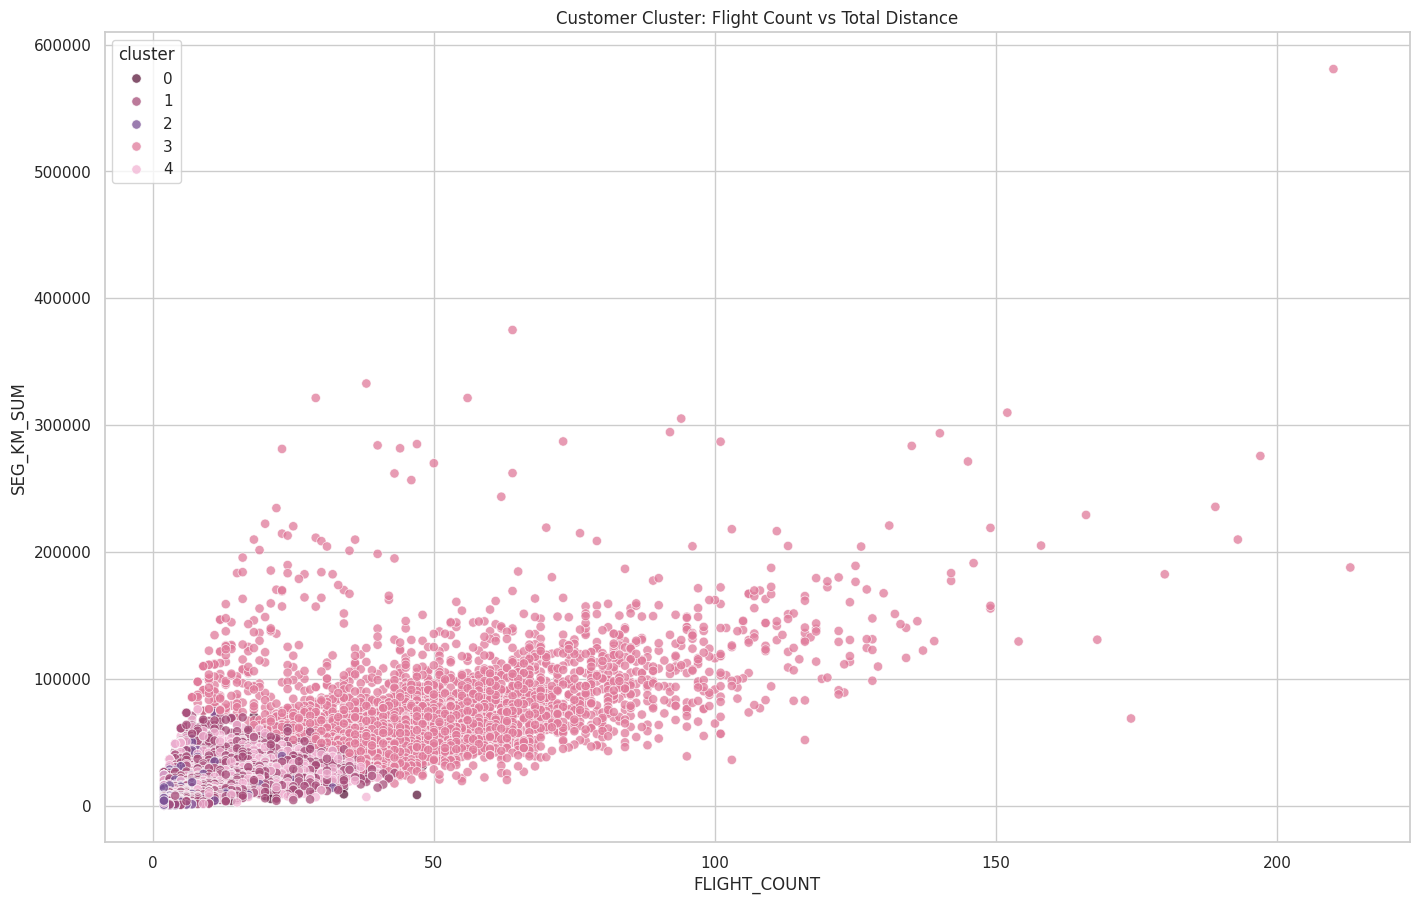

In [30]:
# Visualisasi hasil clustering
fig, ax = plt.subplots(figsize=(15, 10))

sns.scatterplot(
    data=df_cluster,
    x='FLIGHT_COUNT',
    y='SEG_KM_SUM',
    hue='cluster',
    palette=cluster_palette,
    s=45,
    alpha=0.75,
    ax=ax
)

plt.title('Customer Cluster: Flight Count vs Total Distance')
plt.xlabel('FLIGHT_COUNT')
plt.ylabel('SEG_KM_SUM')

plt.show()

In [31]:
centroids = scaler.inverse_transform(kmeans.cluster_centers_)

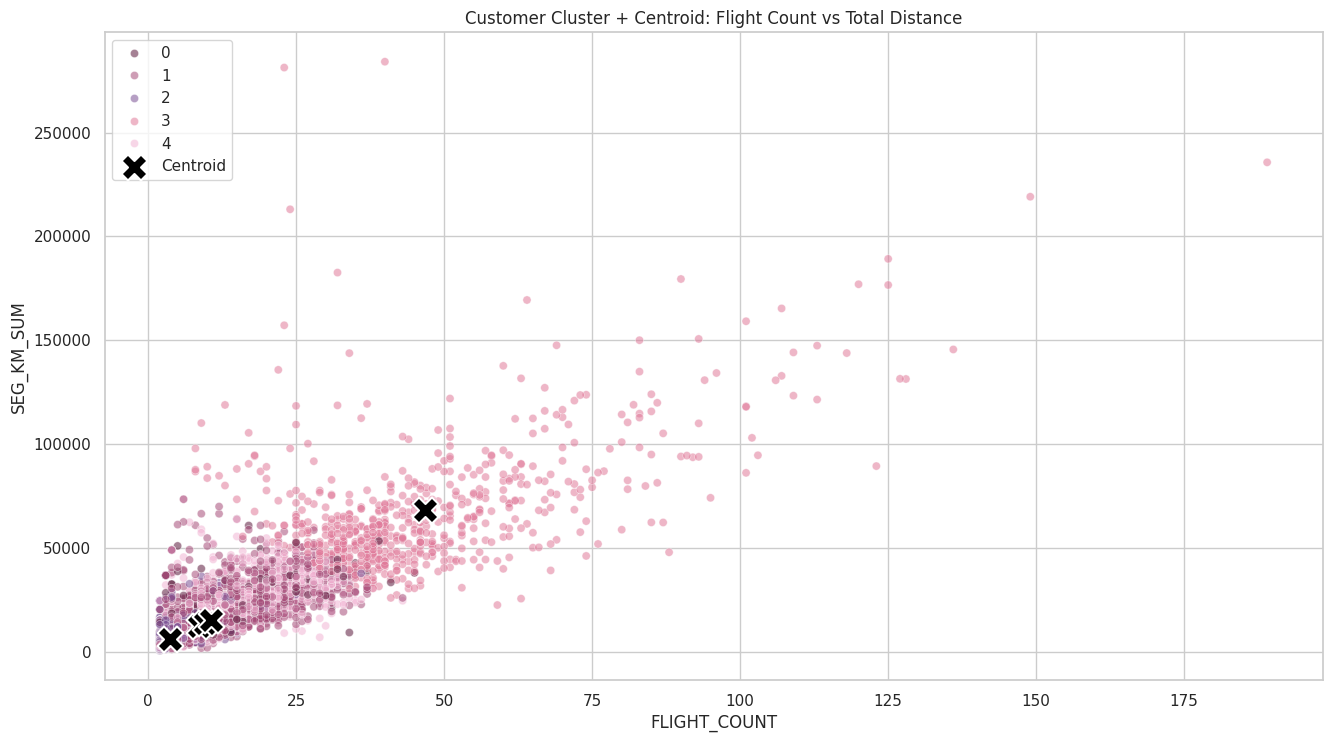

In [32]:
# Sampling hanya untuk membuat plot lebih mudah dibaca; centroid tetap berasal dari seluruh data
plot_sample = df_cluster.sample(n=min(8000, len(df_cluster)), random_state=0)

fig, ax = plt.subplots(figsize=(14, 8))

sns.scatterplot(
    data=plot_sample,
    x='FLIGHT_COUNT',
    y='SEG_KM_SUM',
    hue='cluster',
    palette=cluster_palette,
    s=35,
    alpha=0.55,
    ax=ax
)

# Urutan feature: L(0), LAST_TO_END(1), FLIGHT_COUNT(2), SEG_KM_SUM(3), avg_discount(4)
ax.scatter(
    centroids[:, 2],
    centroids[:, 3],
    c='black',
    s=350,
    marker='X',
    edgecolors='white',
    linewidths=1.5,
    label='Centroid'
)

ax.set_title('Customer Cluster + Centroid: Flight Count vs Total Distance')
ax.set_xlabel('FLIGHT_COUNT')
ax.set_ylabel('SEG_KM_SUM')
ax.legend()
plt.show()


Interpretasi:

- Cluster dengan aktivitas penerbangan sangat tinggi terlihat lebih jelas, sedangkan beberapa cluster lain masih overlap ketika hanya ditampilkan dengan FLIGHT_COUNT dan SEG_KM_SUM.
- Hal ini wajar karena model K-Means dibentuk menggunakan 5 fitur, sedangkan grafik ini hanya menampilkan 2 fitur. Oleh karena itu, PCA digunakan sebagai visualisasi tambahan untuk merangkum kelima fitur ke dua dimensi.

## PCA Visualization

In [33]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca.fit(new_df)
pcs = pca.transform(new_df)

df_pca = pd.DataFrame(data = pcs, columns = ['PC 1', 'PC 2'])
df_pca['cluster'] = kmeans.labels_

df_pca.head()

,PC 1,PC 2,cluster
0,25.948971,-2.460709,3
1,14.752542,0.660846,3
2,14.242071,0.763991,3
3,8.765324,0.480431,3
4,15.314493,-1.176587,3


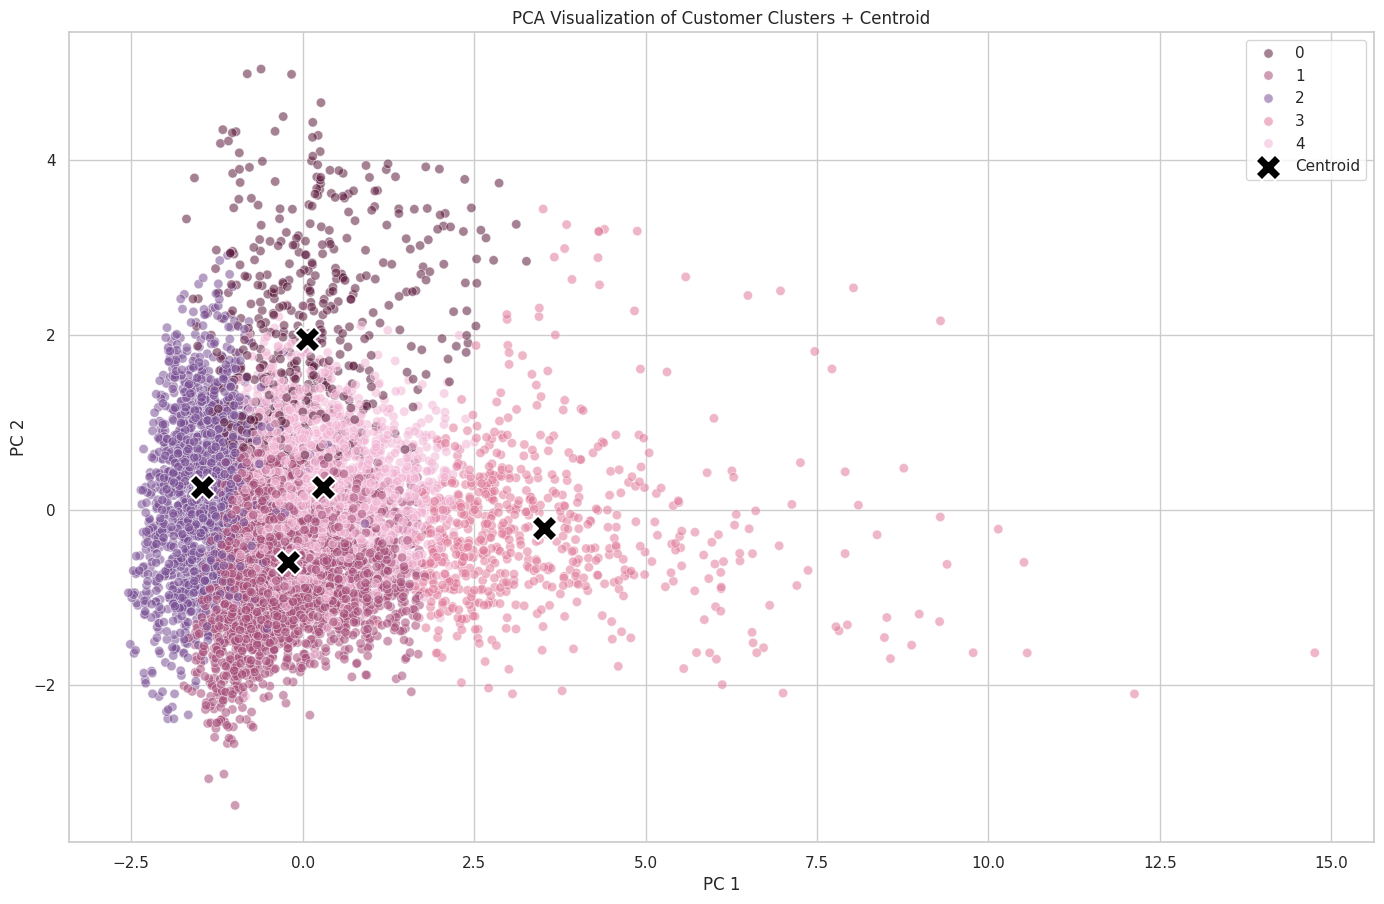

In [35]:
# Sampling hanya untuk membuat plot lebih mudah dibaca; centroid tetap berasal dari seluruh data
pca_plot = df_pca.sample(
    n=8000,
    random_state=0
)

fig, ax = plt.subplots(figsize=(15, 10))

sns.scatterplot(
    data=pca_plot,
    x='PC 1',
    y='PC 2',
    hue='cluster',
    palette= cluster_palette,
    s=45,
    alpha=0.55,
    ax=ax
)

pca_centroids = pca.transform(kmeans.cluster_centers_)

ax.scatter(
    pca_centroids[:, 0],
    pca_centroids[:, 1],
    c='black',
    s=350,
    marker='X',
    edgecolors='white',
    linewidths=1.5,
    label='Centroid'
)

ax.set_title('PCA Visualization of Customer Clusters + Centroid')
ax.legend()

plt.show()

Interpretasi:

- PCA digunakan untuk membantu visualisasi karena clustering menggunakan lima variabel.
- PC1 dan PC2 merupakan kombinasi dari kelima fitur asli, sehingga grafik PCA memberikan gambaran yang lebih menyeluruh dibanding scatter plot dua fitur saja.
- Visualisasi PCA menunjukkan bahwa lima cluster memiliki pola posisi centroid yang berbeda, tetapi sebagian besar titik antar-cluster masih saling overlap.
- Cluster yang berada lebih jauh ke kanan pada PC1 terlihat lebih terpisah dibanding kelompok lain, sedangkan beberapa cluster di area tengah–kiri masih memiliki distribusi yang berdekatan. Hal ini menunjukkan bahwa segmentasi k=5 menghasilkan kelompok dengan karakteristik yang berbeda

# 5. Evaluasi Model

In [36]:
evaluation_df = pd.DataFrame({
    'k': range_n_clusters,
    'silhouette_score': arr_silhouette_score_euclidean,
    'inertia': [inertia[k-1] for k in range_n_clusters]
})

display(evaluation_df.round(4))

,k,silhouette_score,inertia
0,2,0.3711,232663.9006
1,3,0.2646,186834.1997
2,4,0.2710,153137.3903
3,5,0.2792,135422.9968
4,6,0.2821,119923.8936
5,7,0.2448,109272.6301
6,8,0.2279,102252.0189
7,9,0.2383,96620.3295
8,10,0.2328,90256.3819


In [37]:
# Membandingkan mean karakteristik kandidat cluster

for k in [4, 5, 6]:

    print(f'\nMEAN CLUSTER UNTUK k = {k}')

    display(candidate_profiles[k])


MEAN CLUSTER UNTUK k = 4


,L,LAST_TO_END,FLIGHT_COUNT,SEG_KM_SUM,avg_discount
cluster,,,,,
0,29.91,99.80,9.50,13630.42,0.70
1,81.77,108.17,10.52,14962.58,0.74
2,40.61,477.37,3.82,5894.49,0.72
3,63.04,28.19,46.18,67212.89,0.79



MEAN CLUSTER UNTUK k = 5


,L,LAST_TO_END,FLIGHT_COUNT,SEG_KM_SUM,avg_discount
cluster,,,,,
0,51.53,176.33,8.65,12316.24,1.13
1,29.82,98.35,9.64,13835.76,0.68
2,40.33,481.99,3.79,5877.47,0.69
3,63.29,27.67,46.88,68182.44,0.78
4,82.41,106.36,10.64,15174.96,0.69



MEAN CLUSTER UNTUK k = 6


,L,LAST_TO_END,FLIGHT_COUNT,SEG_KM_SUM,avg_discount
cluster,,,,,
0,82.48,120.80,8.51,12135.53,0.69
1,56.79,42.23,29.86,42712.95,0.74
2,69.30,18.33,66.50,98267.34,0.82
3,40.01,488.32,3.79,5852.02,0.70
4,29.25,108.31,7.98,11434.63,0.68
5,54.49,159.94,10.45,15292.03,1.23


Evaluation Interpretation

- k=4 menghasilkan segmentasi yang masih cukup umum dan beberapa cluster memiliki karakteristik yang relatif mirip.
- k=5 menghasilkan lima cluster dengan karakteristik yang lebih jelas dan mudah diinterpretasikan.
- k=6 memiliki Silhouette Score sedikit lebih tinggi dibanding k=5, tetapi memecah customer aktif menjadi kelompok yang lebih granular.
- Selisih Silhouette Score antara k=5 (0.2792) dan k=6 (0.2821) relatif kecil.

jadi, k=5 terpilih sebagai best cluster karena mempertimbangkan Elbow Method, Silhouette Score, perbandingan mean antar cluster, serta kejelasan karakteristik setiap segmen

# 6. Insight dan Rekomendasi

## Cluster Profilling

In [38]:
cluster_profile = df_cluster.groupby('cluster')[feats].mean().round(2)
cluster_profile

,L,LAST_TO_END,FLIGHT_COUNT,SEG_KM_SUM,avg_discount
cluster,,,,,
0,51.53,176.33,8.65,12316.24,1.13
1,29.82,98.35,9.64,13835.76,0.68
2,40.33,481.99,3.79,5877.47,0.69
3,63.29,27.67,46.88,68182.44,0.78
4,82.41,106.36,10.64,15174.96,0.69


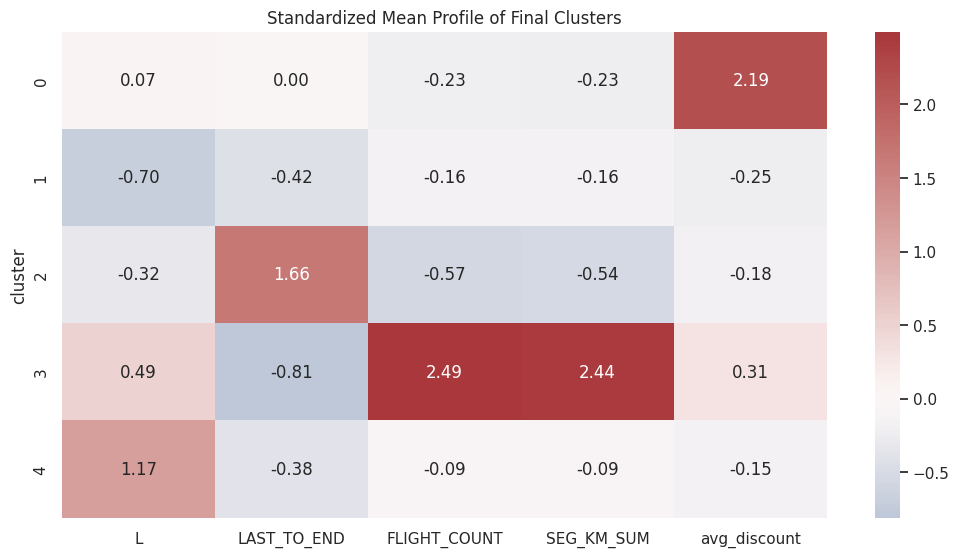

In [39]:
# Profil terstandardisasi: nilai positif = di atas rata-rata, negatif = di bawah rata-rata
profile_std = new_df.copy()
profile_std['cluster'] = kmeans.labels_
profile_std_mean = profile_std.groupby('cluster')[feats].mean()

plt.figure(figsize=(11, 6))
sns.heatmap(
    profile_std_mean,
    annot=True,
    cmap='vlag',
    center=0,
    fmt='.2f'
)
plt.title('Standardized Mean Profile of Final Clusters')
plt.show()


Interpretasi Karakteristik Cluster

Berdasarkan rata-rata setiap fitur:
- Cluster 0 : High Average Discount Customers
Memiliki avg_discount paling tinggi dibanding cluster lain, sementara aktivitas penerbangannya berada pada level rendah–menengah.
- Cluster 1 : New / Developing Regular Customers
Memiliki masa membership (L) paling pendek dengan aktivitas penerbangan yang cukup rutin. Kelompok ini berpotensi dikembangkan menjadi customer yang lebih loyal.
- Cluster 2 : Inactive / At-Risk Customers
Memiliki LAST_TO_END paling tinggi serta FLIGHT_COUNT dan SEG_KM_SUM paling rendah. Artinya customer pada cluster ini sudah lama tidak aktif dan memiliki intensitas perjalanan rendah.
- Cluster 3 : High-Value Active Customers
Memiliki FLIGHT_COUNT dan SEG_KM_SUM jauh paling tinggi serta LAST_TO_END paling rendah. Kelompok ini merupakan customer yang sangat aktif dan bernilai tinggi.
- Cluster 4 : Long-Term Regular Customers
Memiliki masa membership (L) paling panjang dengan aktivitas perjalanan menengah. Kelompok ini menunjukkan hubungan jangka panjang dengan program frequent flyer.

# Business Recomendation

Cluster	Segment	Business Recommendation
1. Cluster 0 (High Average Discount Customers) :	Berikan personalized promotion, discount berbasis rute/season, atau limited-time offer. Hindari blanket discount agar margin tetap terjaga.
2. Cluster 1	(New / Developing Regular Customers) :	Fokus pada onboarding loyalty program, bonus milestone, dan promo setelah beberapa penerbangan untuk meningkatkan engagement dan frekuensi perjalanan.
3. Cluster 2	(Inactive / At-Risk Customers) :	Jalankan reactivation / win-back campaign, reminder mileage/points, dan promo dengan batas waktu untuk mendorong customer kembali terbang.
4. Cluster 3	(High-Value Active Customers)	: Prioritaskan retention melalui priority service, tier benefit, bonus mileage, personalized reward, atau early access promotion.
5. Cluster 4	(Long-Term Regular Customers) :	Berikan loyalty appreciation, anniversary benefit, cross-sell layanan tambahan, serta program untuk meningkatkan frekuensi penerbangan.

# Reflection Questions

1. Mengapa penting melakukan preprocessing dan EDA sebelum menerapkan algoritma clustering seperti K-Means? Jelaskan bagaimana langkah-langkah awal ini berpengaruh terhadap kualitas hasil clustering dan interpretasi cluster.

Answer:
- Preprocessing dan EDA penting dilakukan sebelum K-Means karena kualitas data sangat memengaruhi hasil clustering. Pada tahap preprocessing, data perlu dicek dari missing value, duplicate, tipe data, feature selection, serta perbedaan skala antar fitur. Dalam project ini, fitur seperti SEG_KM_SUM memiliki skala jauh lebih besar dibanding avg_discount, sehingga dilakukan standardisasi agar tidak ada satu fitur yang terlalu mendominasi perhitungan jarak pada K-Means.

- EDA membantu memahami distribusi data, hubungan antar variabel, serta pola awal customer. Contohnya, FLIGHT_COUNT dan SEG_KM_SUM memiliki hubungan positif yang kuat, sehingga customer yang lebih sering terbang cenderung memiliki total jarak perjalanan yang lebih tinggi.

- Dengan preprocessing dan EDA yang baik, cluster yang dihasilkan menjadi lebih representatif dan lebih mudah diinterpretasikan. Tanpa tahap tersebut, cluster dapat terbentuk karena perbedaan skala, missing value, atau variabel yang tidak relevan, bukan karena pola perilaku customer yang sebenarnya.

2. Bagaimana penggunaan metode clustering, seperti K-Means, dapat membantu pengambilan keputusan dalam konteks bisnis nyata? Berikan contoh bagaimana segmentasi pelanggan dapat digunakan untuk strategi pemasaran atau layanan yang lebih tepat sasaran.

Answer:

- K-Means dapat membantu bisnis mengelompokkan customer berdasarkan karakteristik dan pola perilaku yang serupa. Dengan segmentasi tersebut, perusahaan tidak perlu memberikan strategi yang sama kepada seluruh customer, tetapi dapat membuat pendekatan yang lebih sesuai dengan karakter masing-masing kelompok.

- Dalam project airline customer segmentation ini, customer dapat dibedakan berdasarkan lama membership, aktivitas penerbangan terakhir, jumlah penerbangan, total jarak perjalanan, dan rata-rata discount.
- Contohnya, customer yang memiliki frekuensi penerbangan dan total jarak tinggi dapat diberikan loyalty reward, priority service, atau bonus mileage untuk mempertahankan loyalitas mereka.
- Sebaliknya, customer yang sudah lama tidak melakukan penerbangan dan memiliki aktivitas rendah dapat diberikan reactivation campaign seperti promo terbatas atau bonus point agar kembali menggunakan layanan maskapai.
- Dengan demikian, clustering dapat membantu perusahaan membuat strategi marketing, retention, dan customer service yang lebih tepat sasaran serta lebih efisien.
